# Install and Import Libraries

In [1]:
# Install required packages
!pip install nibabel scikit-image -q

# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import nibabel as nib
from sklearn.model_selection import train_test_split
import cv2
from tqdm import tqdm
import warnings
import time
warnings.filterwarnings('ignore')

# Deep Learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, Callback
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence
import tensorflow.keras.backend as K

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("="*70)
print("✅ ALL LIBRARIES IMPORTED SUCCESSFULLY")
print("="*70)
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU'))} GPU(s)")
print("="*70)

2025-11-18 05:22:32.089277: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763443352.284045      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763443352.338851      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

✅ ALL LIBRARIES IMPORTED SUCCESSFULLY
TensorFlow Version: 2.18.0
GPU Available: 2 GPU(s)


# Configuration

In [2]:
# Configuration
class Config:
    # Paths - SAME AS YOUR VIT NOTEBOOK
    DATA_PATH = '/kaggle/input/brats2020-correct-dataset-training-validation'
    TRAIN_PATH = '/kaggle/input/brats2020-correct-dataset-training-validation/BraTS2020 Dataset (Training + Validation)/MICCAI_BraTS2020_TrainingData'
    VAL_PATH = '/kaggle/input/brats2020-correct-dataset-training-validation/BraTS2020 Dataset (Training + Validation)/MICCAI_BraTS2020_ValidationData'
    
    # Preprocessed data paths
    PROCESSED_PATH = '/kaggle/working/processed_data'
    TRAIN_IMAGES_PATH = os.path.join(PROCESSED_PATH, 'train_images.npy')
    TRAIN_MASKS_PATH = os.path.join(PROCESSED_PATH, 'train_masks.npy')
    VAL_IMAGES_PATH = os.path.join(PROCESSED_PATH, 'val_images.npy')
    VAL_MASKS_PATH = os.path.join(PROCESSED_PATH, 'val_masks.npy')
    TEST_IMAGES_PATH = os.path.join(PROCESSED_PATH, 'test_images.npy')
    TEST_MASKS_PATH = os.path.join(PROCESSED_PATH, 'test_masks.npy')
    
    # Model parameters
    IMG_SIZE = 128
    CHANNELS = 4  # T1, T1ce, T2, FLAIR
    NUM_CLASSES = 4  # 0: background, 1: necrotic, 2: edema, 3: enhancing
    BATCH_SIZE = 16 # Reduced for UNETR (larger model)
    EPOCHS = 50
    LEARNING_RATE = 0.0001
    
    # Training parameters - PATIENT-LEVEL SPLIT
    TRAIN_SPLIT = 0.70
    VAL_SPLIT = 0.15
    TEST_SPLIT = 0.15
    SLICE_RANGE = (30, 120)
    
    # UNETR specific parameters
    PATCH_SIZE = 16
    PROJECTION_DIM = 512      
    NUM_HEADS = 8            
    TRANSFORMER_LAYERS = 8    
    TRANSFORMER_UNITS = [1024, 512]  
    DROPOUT = 0.1
    
config = Config()
os.makedirs(config.PROCESSED_PATH, exist_ok=True)

print("="*70)
print("CONFIGURATION FOR UNETR")
print("="*70)
print(f"Image Size: {config.IMG_SIZE}x{config.IMG_SIZE}")
print(f"Channels: {config.CHANNELS}")
print(f"Number of Classes: {config.NUM_CLASSES}")
print(f"Batch Size: {config.BATCH_SIZE}")
print(f"Epochs: {config.EPOCHS}")
print(f"\n🔧 UNETR Parameters:")
print(f"   Patch Size: {config.PATCH_SIZE}x{config.PATCH_SIZE}")
print(f"   Projection Dimension: {config.PROJECTION_DIM}")
print(f"   Number of Attention Heads: {config.NUM_HEADS}")
print(f"   Number of Transformer Layers: {config.TRANSFORMER_LAYERS}")
print(f"   MLP Dimensions: {config.TRANSFORMER_UNITS}")
print(f"   Dropout: {config.DROPOUT}")
print(f"\n📊 Data Split Strategy (PATIENT-LEVEL):")
print(f"   Train: {config.TRAIN_SPLIT*100:.0f}%")
print(f"   Validation: {config.VAL_SPLIT*100:.0f}%")
print(f"   Test: {config.TEST_SPLIT*100:.0f}%")
print("="*70)

CONFIGURATION FOR UNETR
Image Size: 128x128
Channels: 4
Number of Classes: 4
Batch Size: 16
Epochs: 50

🔧 UNETR Parameters:
   Patch Size: 16x16
   Projection Dimension: 512
   Number of Attention Heads: 8
   Number of Transformer Layers: 8
   MLP Dimensions: [1024, 512]
   Dropout: 0.1

📊 Data Split Strategy (PATIENT-LEVEL):
   Train: 70%
   Validation: 15%
   Test: 15%


# Data Loading Functions

In [3]:
def load_nifti(filepath):
    """Load NIfTI file and return numpy array"""
    return nib.load(filepath).get_fdata()

def get_patient_paths(base_path):
    """Get all patient directories"""
    patient_dirs = sorted(glob(os.path.join(base_path, 'BraTS20_Training_*')))
    return patient_dirs

def load_patient_data(patient_dir):
    """Load all modalities and mask for a patient"""
    patient_id = os.path.basename(patient_dir)
    
    # Load modalities
    t1 = load_nifti(os.path.join(patient_dir, f'{patient_id}_t1.nii'))
    t1ce = load_nifti(os.path.join(patient_dir, f'{patient_id}_t1ce.nii'))
    t2 = load_nifti(os.path.join(patient_dir, f'{patient_id}_t2.nii'))
    flair = load_nifti(os.path.join(patient_dir, f'{patient_id}_flair.nii'))
    
    # Load mask (seg file)
    mask = load_nifti(os.path.join(patient_dir, f'{patient_id}_seg.nii'))
    
    # Stack modalities
    image = np.stack([t1, t1ce, t2, flair], axis=-1)
    
    return image, mask

def convert_mask_labels(mask):
    """Convert label 4 to label 3"""
    mask = mask.copy()
    mask[mask == 4] = 3
    return mask

print("✅ Data loading functions defined!")

✅ Data loading functions defined!


# Data Preprocessing Functions

In [4]:
def normalize_image(image):
    """Z-score normalization for each modality"""
    normalized = np.zeros_like(image, dtype=np.float32)
    for i in range(image.shape[-1]):
        modality = image[..., i]
        mean = np.mean(modality)
        std = np.std(modality)
        if std > 0:
            normalized[..., i] = (modality - mean) / std
        else:
            normalized[..., i] = modality - mean
    return normalized

def extract_slices_from_patient(image, mask, slice_range, img_size):
    """Extract and preprocess 2D slices from 3D volume"""
    slices_img = []
    slices_mask = []
    
    start_slice, end_slice = slice_range
    
    for slice_idx in range(start_slice, min(end_slice, image.shape[2])):
        # Extract slice
        img_slice = image[:, :, slice_idx, :]
        mask_slice = mask[:, :, slice_idx]
        
        # Skip if mask is empty (no tumor)
        if np.sum(mask_slice) == 0:
            continue
        
        # Resize
        img_resized = cv2.resize(img_slice, (img_size, img_size), interpolation=cv2.INTER_LINEAR)
        mask_resized = cv2.resize(mask_slice, (img_size, img_size), interpolation=cv2.INTER_NEAREST)
        
        slices_img.append(img_resized)
        slices_mask.append(mask_resized)
    
    return slices_img, slices_mask

def preprocess_dataset_patient_level(patient_paths, slice_range, img_size):
    """Preprocess entire dataset at patient level"""
    all_images = []
    all_masks = []
    
    for patient_dir in tqdm(patient_paths, desc="Processing patients"):
        try:
            # Load patient data
            image, mask = load_patient_data(patient_dir)
            
            # Normalize image
            image = normalize_image(image)
            
            # Convert mask labels
            mask = convert_mask_labels(mask)
            
            # Extract slices
            img_slices, mask_slices = extract_slices_from_patient(image, mask, slice_range, img_size)
            
            all_images.extend(img_slices)
            all_masks.extend(mask_slices)
            
        except Exception as e:
            print(f"Error processing {patient_dir}: {e}")
            continue
    
    # Convert to numpy arrays
    all_images = np.array(all_images, dtype=np.float32)
    all_masks = np.array(all_masks, dtype=np.float32)
    
    return all_images, all_masks

print("✅ Preprocessing functions defined!")

✅ Preprocessing functions defined!


# Split Patients & Process

In [5]:
print("="*70)
print("LOADING AND PREPROCESSING DATA (PATIENT-LEVEL SPLIT)")
print("="*70)

# Get all patient paths
all_patient_paths = get_patient_paths(config.TRAIN_PATH)
print(f"Total patients found: {len(all_patient_paths)}")

# CRITICAL: Split patients FIRST (before extracting slices) to prevent data leakage
train_patients, temp_patients = train_test_split(
    all_patient_paths, 
    test_size=(config.VAL_SPLIT + config.TEST_SPLIT),
    random_state=42
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=config.TEST_SPLIT/(config.VAL_SPLIT + config.TEST_SPLIT),
    random_state=42
)

print(f"\n📊 Patient Split (BEFORE slice extraction):")
print(f"   Training patients: {len(train_patients)}")
print(f"   Validation patients: {len(val_patients)}")
print(f"   Test patients: {len(test_patients)}")

# Now process each patient group separately
print("\n🔄 Processing Training Data...")
X_train, y_train = preprocess_dataset_patient_level(train_patients, config.SLICE_RANGE, config.IMG_SIZE)
print(f"   Training slices: {X_train.shape[0]}")

print("\n🔄 Processing Validation Data...")
X_val, y_val = preprocess_dataset_patient_level(val_patients, config.SLICE_RANGE, config.IMG_SIZE)
print(f"   Validation slices: {X_val.shape[0]}")

print("\n🔄 Processing Test Data...")
X_test, y_test = preprocess_dataset_patient_level(test_patients, config.SLICE_RANGE, config.IMG_SIZE)
print(f"   Test slices: {X_test.shape[0]}")

# Convert masks to one-hot encoding
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=config.NUM_CLASSES)
y_val_cat = tf.keras.utils.to_categorical(y_val, num_classes=config.NUM_CLASSES)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=config.NUM_CLASSES)

print(f"\n✅ Data preprocessing complete!")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train_cat.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val_cat.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test_cat.shape}")
print("="*70)

LOADING AND PREPROCESSING DATA (PATIENT-LEVEL SPLIT)
Total patients found: 369

📊 Patient Split (BEFORE slice extraction):
   Training patients: 258
   Validation patients: 55
   Test patients: 56

🔄 Processing Training Data...


Processing patients: 100%|██████████| 258/258 [07:40<00:00,  1.79s/it]


   Training slices: 15703

🔄 Processing Validation Data...


Processing patients: 100%|██████████| 55/55 [01:31<00:00,  1.66s/it]


   Validation slices: 3335

🔄 Processing Test Data...


Processing patients: 100%|██████████| 56/56 [01:36<00:00,  1.72s/it]


   Test slices: 3290

✅ Data preprocessing complete!
X_train shape: (15703, 128, 128, 4)
y_train shape: (15703, 128, 128, 4)
X_val shape: (3335, 128, 128, 4)
y_val shape: (3335, 128, 128, 4)
X_test shape: (3290, 128, 128, 4)
y_test shape: (3290, 128, 128, 4)


# Visualization

📸 VISUALIZING DATASET SAMPLES


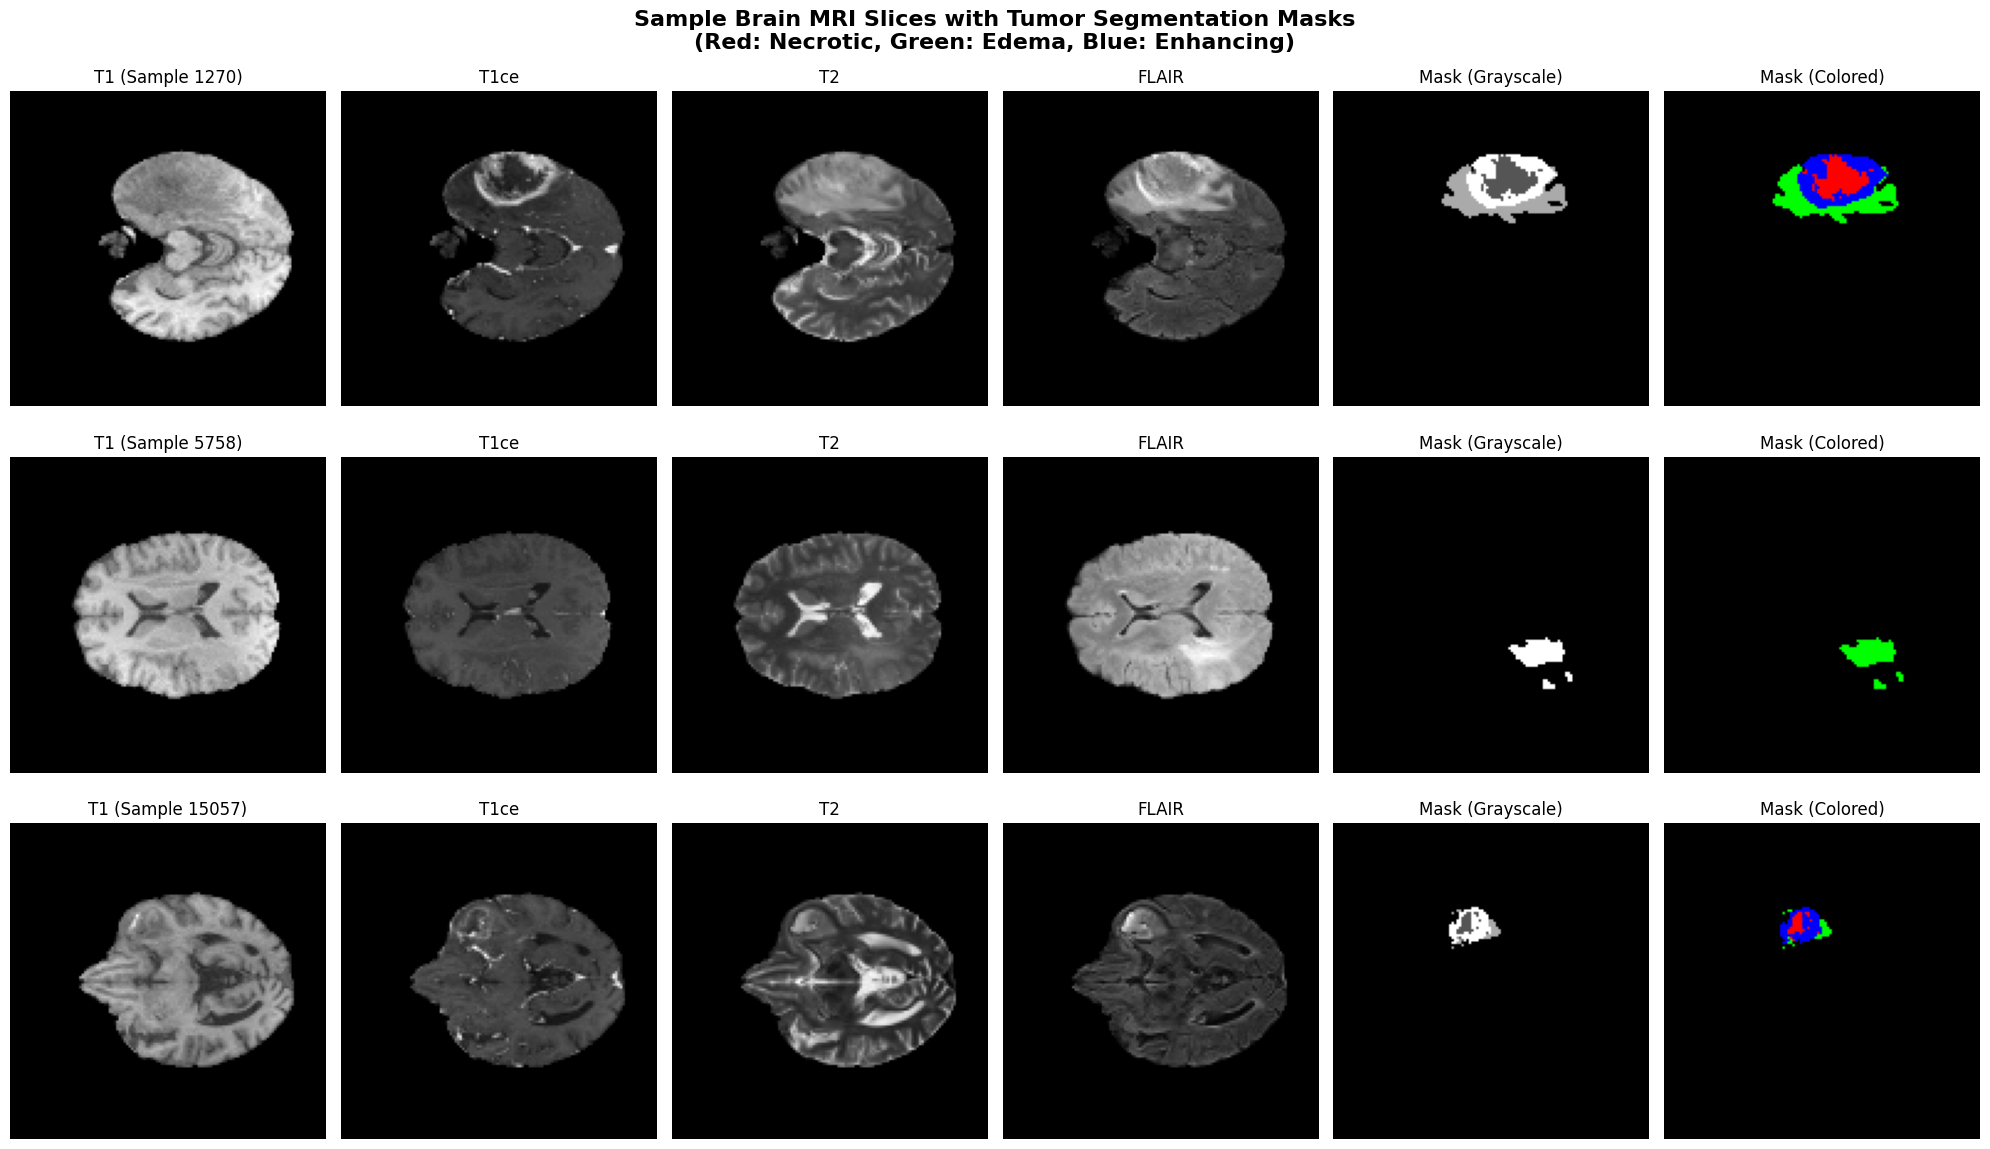


📊 Class Distribution in Training Set:
   Class 0 (Background): 250,326,439 pixels (97.30%)
   Class 1 (Necrotic): 1,457,415 pixels (0.57%)
   Class 2 (Edema): 4,003,246 pixels (1.56%)
   Class 3 (Enhancing): 1,490,852 pixels (0.58%)

✅ Dataset visualization complete!


In [6]:
def visualize_samples(X_data, y_data, num_samples=5):
    """Visualize sample images with all modalities and masks"""
    
    indices = np.random.choice(len(X_data), num_samples, replace=False)
    
    # Color map for segmentation mask
    colors = np.array([
        [0, 0, 0],       # 0: Background - Black
        [255, 0, 0],     # 1: Necrotic - Red
        [0, 255, 0],     # 2: Edema - Green
        [0, 0, 255]      # 3: Enhancing - Blue
    ])
    
    fig, axes = plt.subplots(num_samples, 6, figsize=(20, 4*num_samples))
    
    modality_names = ['T1', 'T1ce', 'T2', 'FLAIR', 'Mask', 'Mask (Colored)']
    
    for i, idx in enumerate(indices):
        # Plot T1
        axes[i, 0].imshow(X_data[idx, :, :, 0], cmap='gray')
        axes[i, 0].set_title(f'T1 (Sample {idx})', fontsize=12)
        axes[i, 0].axis('off')
        
        # Plot T1ce
        axes[i, 1].imshow(X_data[idx, :, :, 1], cmap='gray')
        axes[i, 1].set_title('T1ce', fontsize=12)
        axes[i, 1].axis('off')
        
        # Plot T2
        axes[i, 2].imshow(X_data[idx, :, :, 2], cmap='gray')
        axes[i, 2].set_title('T2', fontsize=12)
        axes[i, 2].axis('off')
        
        # Plot FLAIR
        axes[i, 3].imshow(X_data[idx, :, :, 3], cmap='gray')
        axes[i, 3].set_title('FLAIR', fontsize=12)
        axes[i, 3].axis('off')
        
        # Plot Mask (grayscale)
        axes[i, 4].imshow(y_data[idx], cmap='gray')
        axes[i, 4].set_title('Mask (Grayscale)', fontsize=12)
        axes[i, 4].axis('off')
        
        # Plot Mask (colored)
        mask_colored = colors[y_data[idx].astype(int)]
        axes[i, 5].imshow(mask_colored.astype(np.uint8))
        axes[i, 5].set_title('Mask (Colored)', fontsize=12)
        axes[i, 5].axis('off')
    
    plt.suptitle('Sample Brain MRI Slices with Tumor Segmentation Masks\n'
                 '(Red: Necrotic, Green: Edema, Blue: Enhancing)', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/kaggle/working/dataset_samples.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print class distribution
    print("\n📊 Class Distribution in Training Set:")
    unique, counts = np.unique(y_train.astype(int), return_counts=True)
    total_pixels = y_train.size
    for val, count in zip(unique, counts):
        class_name = ['Background', 'Necrotic', 'Edema', 'Enhancing'][val]
        percentage = (count / total_pixels) * 100
        print(f"   Class {val} ({class_name}): {count:,} pixels ({percentage:.2f}%)")

print("="*70)
print("📸 VISUALIZING DATASET SAMPLES")
print("="*70)

visualize_samples(X_train, y_train, num_samples=3)

print("\n✅ Dataset visualization complete!")
print("="*70)

# Data Generator

In [7]:
class BraTSDataGenerator(Sequence):
    """Memory-efficient data generator for UNETR training"""
    def __init__(self, images, masks, batch_size, shuffle=True, augment=False):
        # DON'T copy the data, just store references
        self.images = images
        self.masks = masks
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.indices = np.arange(len(self.images))
        self.on_epoch_end()
    
    def __len__(self):
        return int(np.floor(len(self.images) / self.batch_size))
    
    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        
        # Only load the batch we need (memory efficient)
        batch_images = np.array([self.images[i] for i in batch_indices], dtype=np.float32)
        batch_masks = np.array([self.masks[i] for i in batch_indices], dtype=np.float32)
        
        if self.augment:
            batch_images, batch_masks = self._augment_batch(batch_images, batch_masks)
        
        return batch_images, batch_masks
    
    def _augment_batch(self, images, masks):
        """Simple augmentation - in place to save memory"""
        for i in range(len(images)):
            # Random horizontal flip
            if np.random.random() > 0.5:
                images[i] = np.flip(images[i], axis=1)
                masks[i] = np.flip(masks[i], axis=1)
            
            # Random vertical flip
            if np.random.random() > 0.5:
                images[i] = np.flip(images[i], axis=0)
                masks[i] = np.flip(masks[i], axis=0)
            
            # Random 90-degree rotation
            if np.random.random() > 0.5:
                k = np.random.randint(1, 4)
                images[i] = np.rot90(images[i], k)
                masks[i] = np.rot90(masks[i], k)
        
        # Make contiguous arrays
        return np.ascontiguousarray(images), np.ascontiguousarray(masks)
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# Create data generators (memory efficient - no data copying)
train_gen = BraTSDataGenerator(X_train, y_train_cat, config.BATCH_SIZE, shuffle=True, augment=True)
val_gen = BraTSDataGenerator(X_val, y_val_cat, config.BATCH_SIZE, shuffle=False, augment=False)
test_gen = BraTSDataGenerator(X_test, y_test_cat, config.BATCH_SIZE, shuffle=False, augment=False)

print("✅ Memory-efficient data generators created!")
print(f"   Training batches: {len(train_gen)}")
print(f"   Validation batches: {len(val_gen)}")
print(f"   Test batches: {len(test_gen)}")

# Test the generator
print("\n🧪 Testing generator output...")
test_batch_x, test_batch_y = train_gen[0]
print(f"   Batch X shape: {test_batch_x.shape}, dtype: {test_batch_x.dtype}")
print(f"   Batch Y shape: {test_batch_y.shape}, dtype: {test_batch_y.dtype}")
print("✅ Generator test passed!")

✅ Memory-efficient data generators created!
   Training batches: 981
   Validation batches: 208
   Test batches: 205

🧪 Testing generator output...
   Batch X shape: (16, 128, 128, 4), dtype: float32
   Batch Y shape: (16, 128, 128, 4), dtype: float32
✅ Generator test passed!


# UNETR - Patch Embedding Layer

In [8]:
class PatchExtract(layers.Layer):
    """Extract patches from images"""
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
    
    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches
    
    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config


class PatchEmbedding(layers.Layer):
    """Embed patches with position encoding"""
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )
    
    def call(self, patches):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patches) + self.position_embedding(positions)
        return encoded
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim
        })
        return config

print("✅ Patch embedding layers defined!")

✅ Patch embedding layers defined!


# UNETR - Transformer Block

In [9]:
class TransformerBlock(layers.Layer):
    """Transformer block with Multi-Head Self-Attention"""
    def __init__(self, projection_dim, num_heads, transformer_units, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.projection_dim = projection_dim
        self.num_heads = num_heads
        self.transformer_units = transformer_units
        self.dropout_rate = dropout_rate
    
    def build(self, input_shape):
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(
            num_heads=self.num_heads, key_dim=self.projection_dim, dropout=self.dropout_rate
        )
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = keras.Sequential([
            layers.Dense(self.transformer_units[0], activation=tf.nn.gelu),
            layers.Dropout(self.dropout_rate),
            layers.Dense(self.transformer_units[1]),
            layers.Dropout(self.dropout_rate),
        ])
        super().build(input_shape)
    
    def call(self, x, training=None):
        # Multi-Head Self-Attention
        x1 = self.norm1(x)
        attention_output = self.attn(x1, x1, training=training)
        x2 = x + attention_output
        
        # MLP
        x3 = self.norm2(x2)
        x3 = self.mlp(x3, training=training)
        return x2 + x3
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "projection_dim": self.projection_dim,
            "num_heads": self.num_heads,
            "transformer_units": self.transformer_units,
            "dropout_rate": self.dropout_rate
        })
        return config

print("✅ Transformer block defined!")

✅ Transformer block defined!


#  UNETR - Build Transformer Encoder with Skip Connections

In [10]:
def build_transformer_encoder(inputs, patch_size, num_patches, projection_dim, 
                               transformer_layers, num_heads, transformer_units, dropout_rate):
    """Build Vision Transformer encoder and extract skip connections"""
    
    # Extract patches
    patches = PatchExtract(patch_size)(inputs)
    
    # Embed patches
    encoded_patches = PatchEmbedding(num_patches, projection_dim)(patches)
    
    # Determine skip connection layers based on total layers
    # UNETR paper uses layers at 1/4, 1/2, 3/4, and final layer
    if transformer_layers == 12:
        skip_layers = [3, 6, 9, 12]
    elif transformer_layers == 8:
        skip_layers = [2, 4, 6, 8]
    elif transformer_layers == 6:
        skip_layers = [2, 3, 5, 6]
    else:
        # Generic: use 1/4, 1/2, 3/4, and final
        skip_layers = [
            max(1, transformer_layers // 4),
            max(2, transformer_layers // 2),
            max(3, 3 * transformer_layers // 4),
            transformer_layers
        ]
    
    print(f"Using skip connections from layers: {skip_layers}")
    
    skip_connections = []
    
    # Apply transformer blocks
    x = encoded_patches
    for i in range(1, transformer_layers + 1):
        x = TransformerBlock(projection_dim, num_heads, transformer_units, dropout_rate)(x)
        
        # Store skip connections
        if i in skip_layers:
            skip_connections.append(x)
    
    return x, skip_connections

print("✅ Transformer encoder builder defined (with dynamic skip connections)!")

✅ Transformer encoder builder defined (with dynamic skip connections)!


# UNETR - CNN Decoder Blocks

In [11]:
def reshape_transformer_output(x, img_size, patch_size, projection_dim):
    """Reshape transformer output from (batch, num_patches, dim) to (batch, H, W, C)"""
    num_patches_side = img_size // patch_size
    x = layers.Reshape((num_patches_side, num_patches_side, projection_dim))(x)
    return x


def conv_block(x, filters, kernel_size=3):
    """Convolutional block: Conv -> BatchNorm -> ReLU -> Conv -> BatchNorm -> ReLU"""
    x = layers.Conv2D(filters, kernel_size, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, kernel_size, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x


def upsample_block(x, skip_connection, filters):
    """Upsample and concatenate with skip connection"""
    x = layers.Conv2DTranspose(filters, (2, 2), strides=2, padding="same")(x)
    x = layers.Concatenate()([x, skip_connection])
    x = conv_block(x, filters)
    return x

print("✅ Decoder blocks defined!")

✅ Decoder blocks defined!


# UNETR - Complete Decoder

In [12]:
def build_unetr_decoder(encoder_output, skip_connections, img_size, patch_size, 
                         projection_dim, num_classes):
    """Build UNETR CNN decoder with proper upsampling of skip connections"""
    
    # All transformer outputs have same spatial size: (img_size/patch_size, img_size/patch_size)
    # For 128x128 image with 16x16 patches: (8, 8)
    # We need to upsample each skip connection to different resolutions
    
    # Reshape all skip connections to spatial dimensions (all are 8x8)
    # skip_connections[0] = layer 3, [1] = layer 6, [2] = layer 9, [3] = layer 12
    
    # z3 (deepest) - keep at 8x8, will be upsampled through decoder
    z3 = reshape_transformer_output(skip_connections[0], img_size, patch_size, projection_dim)
    z3 = conv_block(z3, 512)  # 8x8x512
    
    # z6 - upsample to 16x16
    z6 = reshape_transformer_output(skip_connections[1], img_size, patch_size, projection_dim)
    z6 = layers.Conv2DTranspose(256, (2, 2), strides=2, padding="same")(z6)  # 16x16
    z6 = conv_block(z6, 256)  # 16x16x256
    
    # z9 - upsample to 32x32
    z9 = reshape_transformer_output(skip_connections[2], img_size, patch_size, projection_dim)
    z9 = layers.Conv2DTranspose(128, (2, 2), strides=2, padding="same")(z9)  # 16x16
    z9 = layers.Conv2DTranspose(128, (2, 2), strides=2, padding="same")(z9)  # 32x32
    z9 = conv_block(z9, 128)  # 32x32x128
    
    # z12 - upsample to 64x64
    z12 = reshape_transformer_output(skip_connections[3], img_size, patch_size, projection_dim)
    z12 = layers.Conv2DTranspose(64, (2, 2), strides=2, padding="same")(z12)  # 16x16
    z12 = layers.Conv2DTranspose(64, (2, 2), strides=2, padding="same")(z12)  # 32x32
    z12 = layers.Conv2DTranspose(64, (2, 2), strides=2, padding="same")(z12)  # 64x64
    z12 = conv_block(z12, 64)  # 64x64x64
    
    # Decoder pathway - bottom-up with skip connections
    # Start from z3 (8x8) and progressively upsample
    
    # Upsample z3 from 8x8 to 16x16 and concatenate with z6
    d1 = layers.Conv2DTranspose(512, (2, 2), strides=2, padding="same")(z3)  # 16x16
    d1 = layers.Concatenate()([d1, z6])  # 16x16 + 16x16
    d1 = conv_block(d1, 256)  # 16x16x256
    
    # Upsample to 32x32 and concatenate with z9
    d2 = layers.Conv2DTranspose(256, (2, 2), strides=2, padding="same")(d1)  # 32x32
    d2 = layers.Concatenate()([d2, z9])  # 32x32 + 32x32
    d2 = conv_block(d2, 128)  # 32x32x128
    
    # Upsample to 64x64 and concatenate with z12
    d3 = layers.Conv2DTranspose(128, (2, 2), strides=2, padding="same")(d2)  # 64x64
    d3 = layers.Concatenate()([d3, z12])  # 64x64 + 64x64
    d3 = conv_block(d3, 64)  # 64x64x64
    
    # Upsample to 128x128 (final resolution)
    d4 = layers.Conv2DTranspose(64, (2, 2), strides=2, padding="same")(d3)  # 128x128
    d4 = conv_block(d4, 32)  # 128x128x32
    
    # Final segmentation layer
    outputs = layers.Conv2D(num_classes, 1, padding="same", activation="softmax")(d4)
    
    return outputs

print("✅ UNETR decoder defined (FIXED)!")

✅ UNETR decoder defined (FIXED)!


# Build Complete UNETR Model

In [13]:
def build_unetr_model():
    """Build complete UNETR model"""
    
    # Calculate number of patches
    num_patches = (config.IMG_SIZE // config.PATCH_SIZE) ** 2
    
    # Input
    inputs = layers.Input(shape=(config.IMG_SIZE, config.IMG_SIZE, config.CHANNELS))
    
    # Transformer Encoder with skip connections
    encoder_output, skip_connections = build_transformer_encoder(
        inputs=inputs,
        patch_size=config.PATCH_SIZE,
        num_patches=num_patches,
        projection_dim=config.PROJECTION_DIM,
        transformer_layers=config.TRANSFORMER_LAYERS,
        num_heads=config.NUM_HEADS,
        transformer_units=config.TRANSFORMER_UNITS,
        dropout_rate=config.DROPOUT
    )
    
    # CNN Decoder
    outputs = build_unetr_decoder(
        encoder_output=encoder_output,
        skip_connections=skip_connections,
        img_size=config.IMG_SIZE,
        patch_size=config.PATCH_SIZE,
        projection_dim=config.PROJECTION_DIM,
        num_classes=config.NUM_CLASSES
    )
    
    # Create model
    model = Model(inputs=inputs, outputs=outputs, name="UNETR")
    
    return model

# Build model
unetr_model = build_unetr_model()

print("="*70)
print("UNETR MODEL ARCHITECTURE")
print("="*70)
unetr_model.summary()
print("="*70)

I0000 00:00:1763444058.732432      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1763444058.733916      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Using skip connections from layers: [2, 4, 6, 8]
UNETR MODEL ARCHITECTURE


Model: "UNETR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_extract       │ (None, None,      │          0 │ input_layer[0][0] │
│ (PatchExtract)      │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_embedding     │ (None, 64, 512)   │    557,568 │ patch_extract[0]… │
│ (PatchEmbedding)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block   │ (None, 64, 512)   │  9,453,568 │ patch_embedding[… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_1 │ (None, 64, 512)   │  9,453,568 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_2 │ (None, 64, 512)   │  9,453,568 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_3 │ (None, 64, 512)   │  9,453,568 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 8, 8, 512) │          0 │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 8, 8, 512) │          0 │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 8, 8, 512) │  2,359,808 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │    524,544 │ reshape_1[0][0]   │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 8, 8, 512) │      2,048 │ conv2d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_transpose… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 8, 8, 512) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 8, 8, 512) │  2,359,808 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 512) │      2,048 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 88,001,860 (335.70 MB)

 Trainable params: 87,996,100 (335.68 MB)

 Non-trainable params: 5,760 (22.50 KB)

# Loss Functions and Metrics

In [14]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """Calculate Dice coefficient"""
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


def dice_loss(y_true, y_pred):
    """Dice loss for multi-class segmentation"""
    loss = 0
    for i in range(config.NUM_CLASSES):
        loss += 1 - dice_coefficient(y_true[..., i], y_pred[..., i])
    return loss / config.NUM_CLASSES


def categorical_focal_loss(y_true, y_pred, gamma=2.0, alpha=0.25):
    """Focal loss for handling class imbalance"""
    epsilon = K.epsilon()
    y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
    cross_entropy = -y_true * K.log(y_pred)
    focal_loss = alpha * K.pow(1 - y_pred, gamma) * cross_entropy
    return K.mean(K.sum(focal_loss, axis=-1))


def dice_focal_loss(y_true, y_pred):
    """Combined Dice and Focal loss"""
    dice = dice_loss(y_true, y_pred)
    focal = categorical_focal_loss(y_true, y_pred, gamma=2.0, alpha=0.25)
    return dice + focal


def iou_score(y_true, y_pred, smooth=1e-6):
    """Intersection over Union score"""
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

print("✅ Loss functions and metrics defined!")

✅ Loss functions and metrics defined!


# Compile Model

In [15]:
# Compile model
unetr_model.compile(
    optimizer=Adam(learning_rate=config.LEARNING_RATE),
    loss=dice_focal_loss,
    metrics=[dice_coefficient, iou_score, 'accuracy']
)

print("✅ Model compiled successfully!")
print(f"   Optimizer: Adam (lr={config.LEARNING_RATE})")
print(f"   Loss: Dice + Focal Loss")
print(f"   Metrics: Dice Coefficient, IoU Score, Accuracy")

✅ Model compiled successfully!
   Optimizer: Adam (lr=0.0001)
   Loss: Dice + Focal Loss
   Metrics: Dice Coefficient, IoU Score, Accuracy


# Training Callbacks

In [16]:
# Model checkpoint
checkpoint = ModelCheckpoint(
    '/kaggle/working/unetr_best_model.keras',
    monitor='val_dice_coefficient',
    mode='max',
    save_best_only=True,
    verbose=1
)

# Early stopping
early_stopping = EarlyStopping(
    monitor='val_dice_coefficient',
    mode='max',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Learning rate reduction
reduce_lr = ReduceLROnPlateau(
    monitor='val_dice_coefficient',
    mode='max',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Time callback
class TimeCallback(Callback):
    def on_train_begin(self, logs=None):
        self.times = []
        self.total_time = time.time()
    
    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_time_start = time.time()
    
    def on_epoch_end(self, epoch, logs=None):
        self.times.append(time.time() - self.epoch_time_start)
    
    def on_train_end(self, logs=None):
        self.total_time = time.time() - self.total_time

time_callback = TimeCallback()

callbacks = [checkpoint, early_stopping, reduce_lr, time_callback]

print("✅ Callbacks configured!")

✅ Callbacks configured!


# Train the Model

In [17]:
print("="*70)
print("🚀 STARTING UNETR TRAINING")
print("="*70)

history = unetr_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=config.EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*70)
print("✅ TRAINING COMPLETED!")
print(f"Total training time: {time_callback.total_time/60:.2f} minutes")
print(f"Average time per epoch: {np.mean(time_callback.times):.2f} seconds")
print("="*70)

🚀 STARTING UNETR TRAINING
Epoch 1/50


I0000 00:00:1763444093.668650     119 service.cc:148] XLA service 0x7dbab80060f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763444093.669301     119 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1763444093.669323     119 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1763444098.576509     119 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1763444135.950015     119 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.9228 - dice_coefficient: 0.6404 - iou_score: 0.4902 - loss: 0.7934
Epoch 1: val_dice_coefficient improved from -inf to 0.94155, saving model to /kaggle/working/unetr_best_model.keras
981/981 ━━━━━━━━━━━━━━━━━━━━ 639s 575ms/step - accuracy: 0.9228 - dice_coefficient: 0.6406 - iou_score: 0.4904 - loss: 0.7933 - val_accuracy: 0.9795 - val_dice_coefficient: 0.9415 - val_iou_score: 0.8898 - val_loss: 0.6107 - learning_rate: 1.0000e-04
Epoch 2/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.9837 - dice_coefficient: 0.9644 - iou_score: 0.9315 - loss: 0.4465
Epoch 2: val_dice_coefficient improved from 0.94155 to 0.98202, saving model to /kaggle/working/unetr_best_model.keras
981/981 ━━━━━━━━━━━━━━━━━━━━ 564s 575ms/step - accuracy: 0.9837 - dice_coefficient: 0.9644 - iou_score: 0.9316 - loss: 0.4464 - val_accuracy: 0.9842 - val_dice_coefficient: 0.9820 - val_iou_score: 0.9650 - val_loss: 0.5176 - learning_rate: 1.0000e-04
Epoc

# Plot Training History

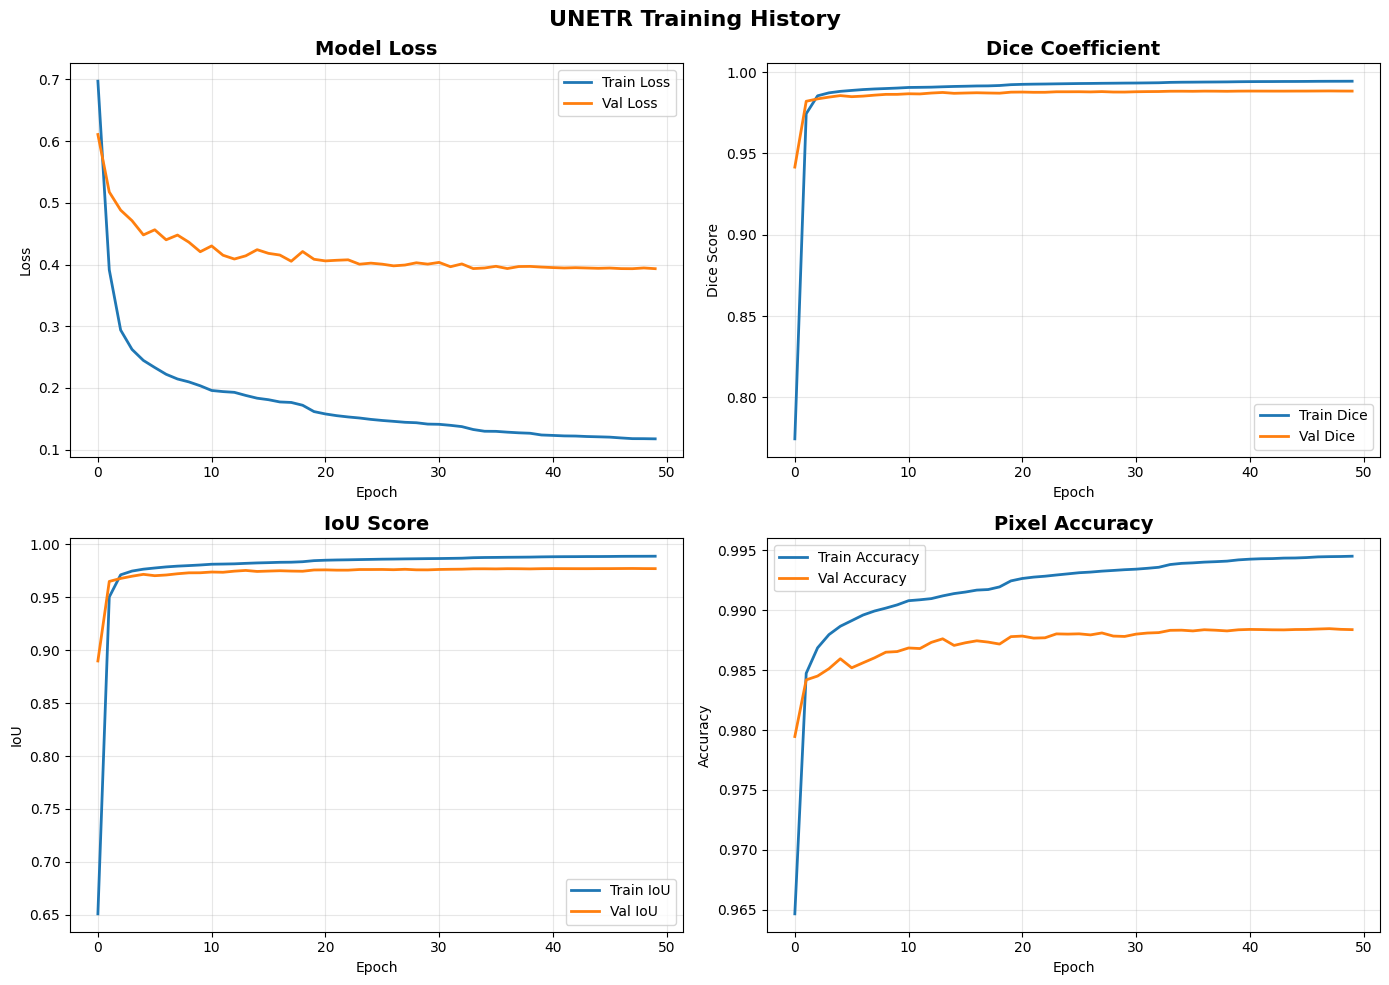

✅ Training history plotted and saved!


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Dice Coefficient
axes[0, 1].plot(history.history['dice_coefficient'], label='Train Dice', linewidth=2)
axes[0, 1].plot(history.history['val_dice_coefficient'], label='Val Dice', linewidth=2)
axes[0, 1].set_title('Dice Coefficient', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Dice Score')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# IoU Score
axes[1, 0].plot(history.history['iou_score'], label='Train IoU', linewidth=2)
axes[1, 0].plot(history.history['val_iou_score'], label='Val IoU', linewidth=2)
axes[1, 0].set_title('IoU Score', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('IoU')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Accuracy
axes[1, 1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1, 1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1, 1].set_title('Pixel Accuracy', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('UNETR Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/unetr_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training history plotted and saved!")

# Evaluate on Test Set

In [19]:
print("="*70)
print("📊 EVALUATING UNETR ON TEST SET")
print("="*70)

# Load best model
best_model = tf.keras.models.load_model(
    '/kaggle/working/unetr_best_model.keras',
    custom_objects={
        'dice_focal_loss': dice_focal_loss,
        'dice_coefficient': dice_coefficient,
        'iou_score': iou_score,
        'PatchExtract': PatchExtract,
        'PatchEmbedding': PatchEmbedding,
        'TransformerBlock': TransformerBlock
    }
)

test_results = best_model.evaluate(test_gen, verbose=1)

print("\n" + "="*70)
print("TEST RESULTS")
print("="*70)
print(f"Test Loss: {test_results[0]:.4f}")
print(f"Test Dice Coefficient: {test_results[1]:.4f}")
print(f"Test IoU Score: {test_results[2]:.4f}")
print(f"Test Accuracy: {test_results[3]:.4f}")
print("="*70)

📊 EVALUATING UNETR ON TEST SET
205/205 ━━━━━━━━━━━━━━━━━━━━ 29s 113ms/step - accuracy: 0.9891 - dice_coefficient: 0.9890 - iou_score: 0.9784 - loss: 0.3897

TEST RESULTS
Test Loss: 0.4062
Test Dice Coefficient: 0.9878
Test IoU Score: 0.9762
Test Accuracy: 0.9879


# Per-Class Evaluation

In [20]:
def evaluate_per_class(model, X_test, y_test_cat, class_names):
    """Evaluate model performance per class"""
    predictions = model.predict(X_test, verbose=1)
    
    dice_scores = {}
    iou_scores = {}
    
    for i, class_name in enumerate(class_names):
        pred_class = predictions[..., i]
        true_class = y_test_cat[..., i]
        
        # Calculate Dice
        intersection = np.sum(pred_class * true_class)
        union_dice = np.sum(pred_class) + np.sum(true_class)
        dice = (2. * intersection + 1e-6) / (union_dice + 1e-6)
        
        # Calculate IoU
        union_iou = union_dice - intersection
        iou = (intersection + 1e-6) / (union_iou + 1e-6)
        
        dice_scores[class_name] = dice
        iou_scores[class_name] = iou
    
    return dice_scores, iou_scores

class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']

print("="*70)
print("PER-CLASS EVALUATION")
print("="*70)

dice_scores, iou_scores = evaluate_per_class(best_model, X_test, y_test_cat, class_names)

for class_name in class_names:
    print(f"\n{class_name}:")
    print(f"   Dice Score: {dice_scores[class_name]:.4f}")
    print(f"   IoU Score: {iou_scores[class_name]:.4f}")

print(f"\nMean Dice Score: {np.mean(list(dice_scores.values())):.4f}")
print(f"Mean IoU Score: {np.mean(list(iou_scores.values())):.4f}")
print("="*70)

PER-CLASS EVALUATION
103/103 ━━━━━━━━━━━━━━━━━━━━ 40s 288ms/step

Background:
   Dice Score: 0.9963
   IoU Score: 0.9927

Necrotic:
   Dice Score: 0.5858
   IoU Score: 0.4142

Edema:
   Dice Score: 0.7251
   IoU Score: 0.5688

Enhancing:
   Dice Score: 0.7210
   IoU Score: 0.5638

Mean Dice Score: 0.7571
Mean IoU Score: 0.6349


# Visualize Predictions

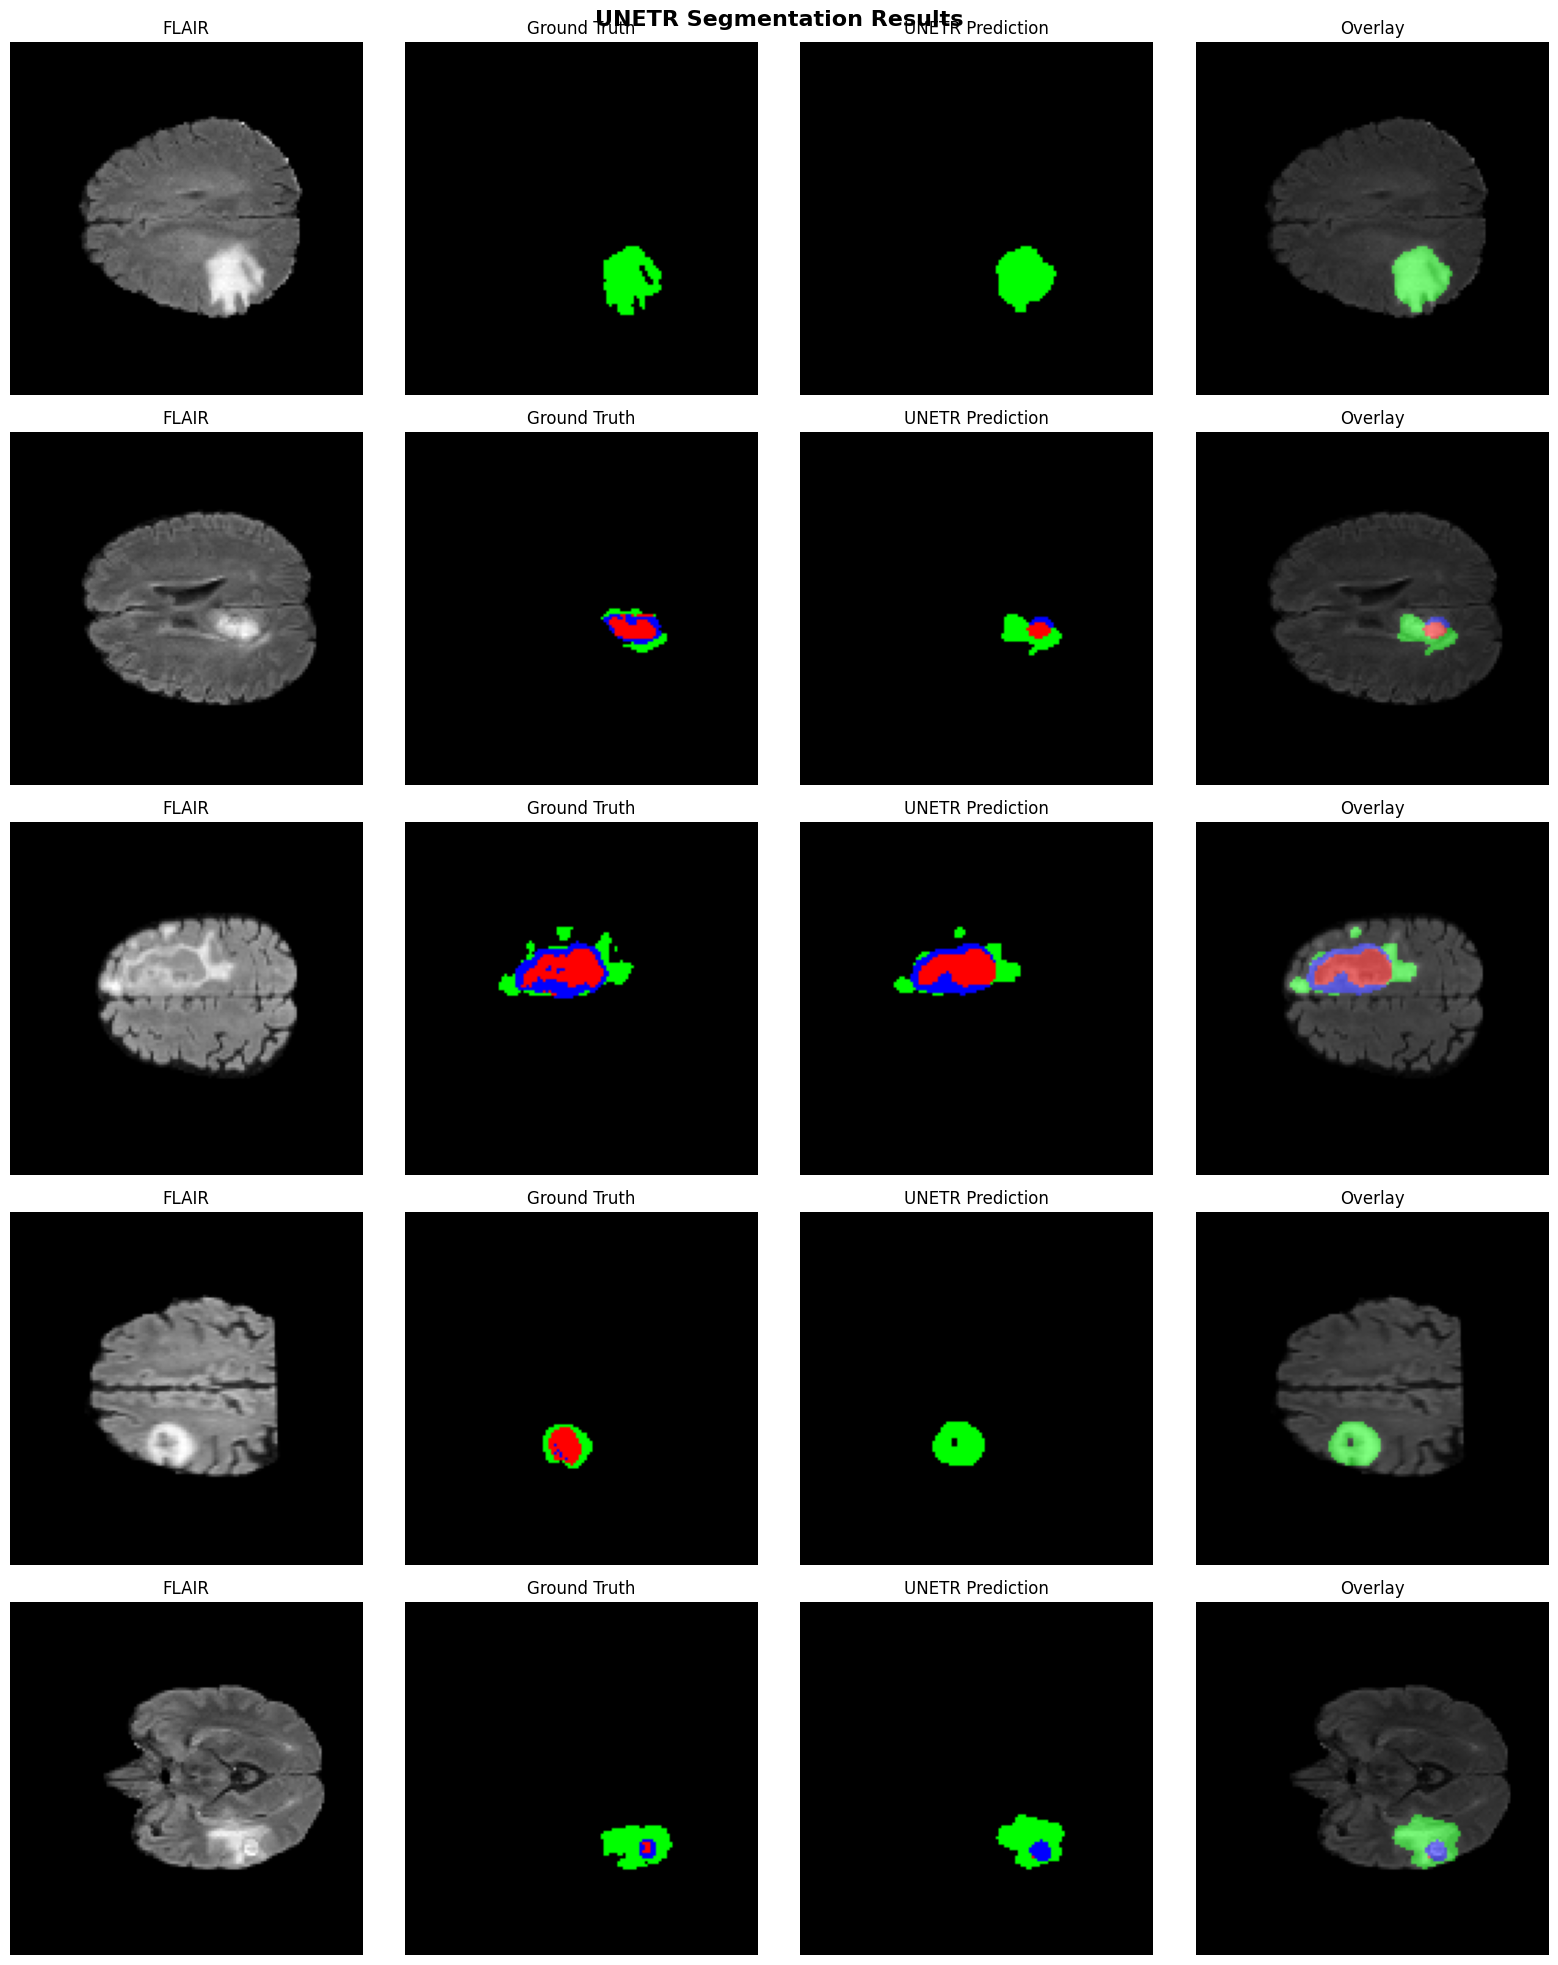

✅ Predictions visualized and saved!


In [21]:
def plot_predictions(model, X_test, y_test, num_samples=5):
    """Visualize model predictions"""
    indices = np.random.choice(len(X_test), num_samples, replace=False)
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
    
    # Color map for segmentation
    colors = np.array([
        [0, 0, 0],       # Background - Black
        [255, 0, 0],     # Necrotic - Red
        [0, 255, 0],     # Edema - Green
        [0, 0, 255]      # Enhancing - Blue
    ])
    
    for i, idx in enumerate(indices):
        pred = model.predict(X_test[idx:idx+1], verbose=0)[0]
        pred_mask = np.argmax(pred, axis=-1)
        true_mask = np.argmax(y_test[idx], axis=-1)
        
        pred_colored = colors[pred_mask]
        true_colored = colors[true_mask]
        
        # FLAIR modality
        axes[i, 0].imshow(X_test[idx, :, :, 3], cmap='gray')
        axes[i, 0].set_title('FLAIR', fontsize=12)
        axes[i, 0].axis('off')
        
        # Ground Truth
        axes[i, 1].imshow(true_colored.astype(np.uint8))
        axes[i, 1].set_title('Ground Truth', fontsize=12)
        axes[i, 1].axis('off')
        
        # Prediction
        axes[i, 2].imshow(pred_colored.astype(np.uint8))
        axes[i, 2].set_title('UNETR Prediction', fontsize=12)
        axes[i, 2].axis('off')
        
        # Overlay
        axes[i, 3].imshow(X_test[idx, :, :, 3], cmap='gray')
        axes[i, 3].imshow(pred_colored.astype(np.uint8), alpha=0.5)
        axes[i, 3].set_title('Overlay', fontsize=12)
        axes[i, 3].axis('off')
    
    plt.suptitle('UNETR Segmentation Results', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/kaggle/working/unetr_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_predictions(best_model, X_test, y_test_cat, num_samples=5)
print("✅ Predictions visualized and saved!")

# Confusion Matrix

Generating predictions for confusion matrix...
103/103 ━━━━━━━━━━━━━━━━━━━━ 20s 194ms/step


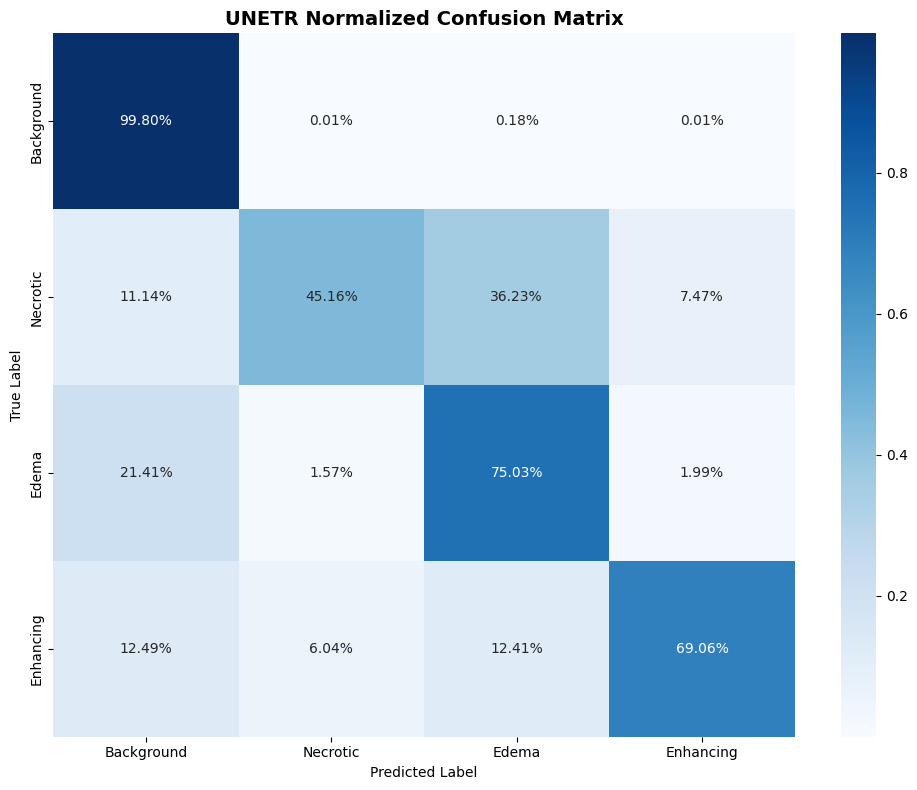


CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Background     0.9947    0.9980    0.9963   4851182
    Necrotic     0.8499    0.4516    0.5898     39016
       Edema     0.7066    0.7503    0.7278     84327
   Enhancing     0.7679    0.6906    0.7272     25475

    accuracy                         0.9879   5000000
   macro avg     0.8298    0.7226    0.7603   5000000
weighted avg     0.9876    0.9879    0.9873   5000000



In [22]:
from sklearn.metrics import confusion_matrix, classification_report

print("Generating predictions for confusion matrix...")
predictions = best_model.predict(X_test, verbose=1)
pred_masks = np.argmax(predictions, axis=-1).flatten()
true_masks = np.argmax(y_test_cat, axis=-1).flatten()

# Sample for efficiency (if dataset is very large)
sample_size = min(len(pred_masks), 5000000)
indices = np.random.choice(len(pred_masks), sample_size, replace=False)
pred_sample = pred_masks[indices]
true_sample = true_masks[indices]

# Confusion Matrix
cm = confusion_matrix(true_sample, pred_sample)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('UNETR Normalized Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/kaggle/working/unetr_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(true_sample, pred_sample, target_names=class_names, digits=4))
print("="*70)